# CMA-ES

In [ ]:
# ! pip install cma "gymnasium[box2d]>=1.0" "stable-baselines3>=2.3"

In [2]:
import numpy as np
import cma
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import gymnasium
import torch
import torch.nn as nn
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from typing import Callable

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam and Momentum.

In [3]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

### Helper functions

Convergence plot and animation.

In [4]:
def plot_convergence(histories: dict[str, list[float]]) -> None:
    plt.figure()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("CMA-ES Convergence")
    plt.legend()
    plt.grid(True)
    plt.show()

def animate_distribution(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
    filename: str = "cma_es_animation.mp4",
) -> None:
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots()
    levels = np.logspace(np.log10(Z.min() + 1e-6), np.log10(Z.max()), 30)

    def update(frame_index: int) -> None:
        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")
        mu = mu_history[frame_index]
        cov = cov_history[frame_index]
        vals, vecs = np.linalg.eigh(cov)
        angle = float(np.degrees(np.arctan2(vecs[0, 1], vecs[0, 0])))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")
        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

    anim = FuncAnimation(fig, update, frames=min(frames, len(mu_history)), interval=200)
    anim.save(filename, writer="ffmpeg")
    print(f"Animation saved to {filename}")

### Running CMA-ES

In [39]:
from dataclasses import dataclass

@dataclass
class CMAESResult:
    best_fitness: list[float]
    mean_history: list[np.ndarray]
    cov_history: list[np.ndarray]
    sigma_history: list[float]

def run_cma_es(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 100
) -> CMAESResult:
    # TODO: Implement this function
    # TODO: Use cma.CMAEvolutionStrategy from pycma: https://pypi.org/project/cma/
    # Hint: Use ask and tell methods

    best_fitness = []
    mean_history = []
    cov_history = []
    sigma_history = []

    evaluation_count = 0

    es = cma.CMAEvolutionStrategy(x0, sigma0)
    for _ in range(max_iterations):
        if es.stop():
            break
        solutions = es.ask()
        evaluation_count += len(solutions)

        fitnesses = [func(sol) for sol in solutions]
        es.tell(solutions, fitnesses)

        best_fitness.append(min(fitnesses))
        mean_history.append(es.mean.copy())
        cov_history.append(es.C.copy())
        sigma_history.append(es.sigma)

        # if min(fitnesses) < 1e-8:
            # break

    result = CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history,
        
    )   
    result.total_evaluations = evaluation_count
    result.success = best_fitness[-1] < 1e-8
    
    return result


### Ex. 1: Impact of the Starting Point
1.	Choose Rosenbrock in 2D.
2.	Run CMA-ES from at least five widely separated initial means (e.g., [-4,-4], [-1,3], [5,5]).
3.	Plot convergence curves and report:
- best fitness vs. generation,
- total evaluations to reach $f(x)\lt10^{-8}$ (or termination).
4.	Briefly discuss sensitivity to the start point. Prepare GIFs for two different starting points.

Hint: use `sigma0 = 0.5` and `max_iter = 250`.

Starting Point  | Evaluations | Status     | Final f(x)
------------------------------------------------------------
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=271058, Thu May  7 15:24:09 2026)
[-4, -4]        | 420        | SUCCESS    | 2.86e-09
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=339764, Thu May  7 15:24:09 2026)
[-1,  3]        | 738        | SUCCESS    | 7.92e-09
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=280377, Thu May  7 15:24:10 2026)
[ 5,  5]        | 408        | SUCCESS    | 1.66e-09
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=237795, Thu May  7 15:24:10 2026)
[ 4, -4]        | 342        | SUCCESS    | 2.21e-09
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=206032, Thu May  7 15:24:10 2026)
[-3, -1]        | 486        | SUCCESS    | 5.19e-10


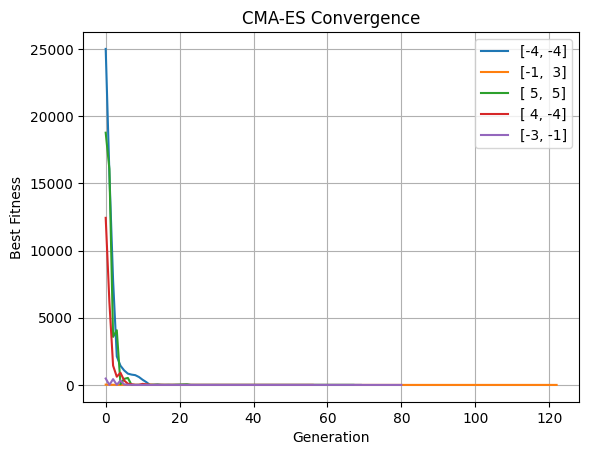

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to rosenbrock_start_minus4.gif


MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to rosenbrock_start_5_5.gif


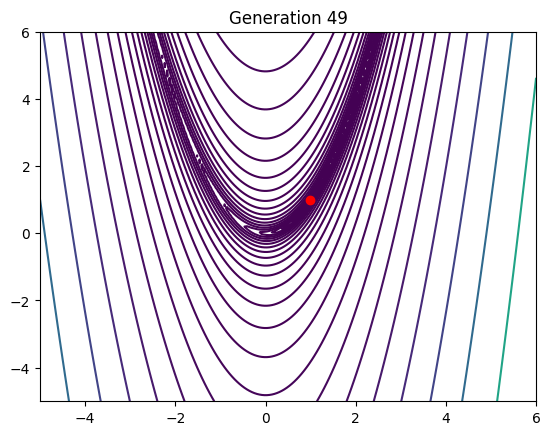

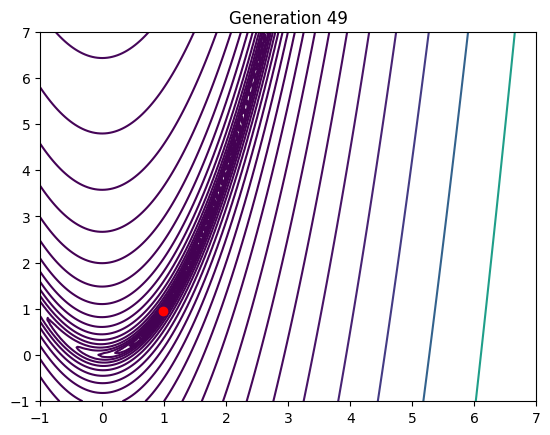

In [16]:
start_points = {
        "[-4, -4]": np.array([-4.0, -4.0]),
        "[-1,  3]": np.array([-1.0, 3.0]),
        "[ 5,  5]": np.array([5.0, 5.0]),
        "[ 4, -4]": np.array([4.0, -4.0]),
        "[-3, -1]": np.array([-3.0, -1.0])
    }
sigma0 = 0.5
max_iter = 250
    
histories = {}
results = {}
    
print(f"{'Starting Point':<15} | {'Evaluations':<10} | {'Status':<10} | {'Final f(x)'}")
print("-" * 60)
    
for name, x0 in start_points.items():
    res = run_cma_es(rosenbrock, x0, sigma0, max_iter)
    histories[name] = res.best_fitness
    results[name] = res
        
    status = "SUCCESS" if res.success else "LIMIT"
    print(f"{name:<15} | {res.total_evaluations:<10d} | {status:<10} | {res.best_fitness[-1]:.2e}")

plot_convergence(histories)

animate_distribution(rosenbrock, results["[-4, -4]"].mean_history, results["[-4, -4]"].cov_history, bounds=(-5, 6), filename="rosenbrock_start_minus4.gif")
animate_distribution(rosenbrock, results["[ 5,  5]"].mean_history, results["[ 5,  5]"].cov_history, bounds=(-1, 7), filename="rosenbrock_start_5_5.gif")


- Robustness: The algorithm successfully found the global optimum ($f(x) < 10^{-8}$) from all five starting points, proving its reliability.
- Computational Cost: The convergence speed varied significantly depending on the initial location, ranging from 342 to 738 evaluations.
- Path Geometry: Starting at [-1, 3] was the most expensive (738 evaluations), as it likely forced the algorithm to navigate steep, curving ridges to reach the center. In contrast, starting at [4, -4] was the most efficient (342 evaluations), allowing the algorithm to quickly drop into the main valley and smoothly adapt its covariance matrix towards the minimum at $(1,1)$.
- Summary: The start point does not dictate if the algorithm succeeds, but its position relative to the function's topography heavily dictates the computational cost (total evaluations) required to get there.

### Ex. 2: Effect of the Initial Global Step‐Size $\sigma_0$
1. Use [2,2] at starting point on the Rastrigin function.
2. Test $\sigma_0\in\{0.1,\,0.5,\,1,\,2,\,5\}$.
3. Record and plot
- final fitness after a fixed budget (e.g. 1000 evals)
- evolution of es.sigma over time (log scale).
4. Explain why too-small and too-large $\sigma_0$ hurt performance, relating findings to the adaptation rule.

Initial Sigma   | Final f(x)      | Evaluations
--------------------------------------------------
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=246923, Thu May  7 16:08:24 2026)
0.1             | 7.96e+00        | 438
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=182643, Thu May  7 16:08:24 2026)
0.5             | 7.96e+00        | 510
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=241586, Thu May  7 16:08:24 2026)
1.0             | 1.99e+00        | 600
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=224620, Thu May  7 16:08:24 2026)
2.0             | 9.95e-01        | 762
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=300637, Thu May  7 16:08:24 2026)
5.0             | 1.99e+00        | 570


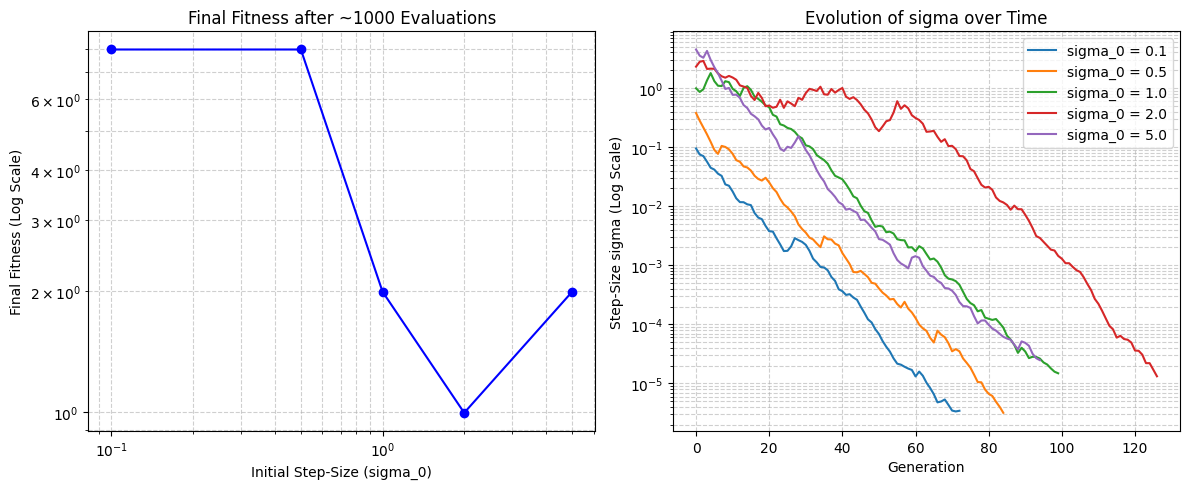

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_experiment_2():
    # 1. Setup
    x0 = np.array([2.0, 2.0])
    sigmas = [0.1, 0.5, 1.0, 2.0, 5.0]
    max_iter = 167  # 

    final_fitnesses = []
    sigma_histories = {}

    print(f"{'Initial Sigma':<15} | {'Final f(x)':<15} | {'Evaluations'}")
    print("-" * 50)

    for s0 in sigmas:
        res = run_cma_es(func=rastrigin, x0=x0, sigma0=s0, max_iterations=max_iter)
        
        final_fit = res.best_fitness[-1]
        final_fitnesses.append(final_fit)
        sigma_histories[f"sigma_0 = {s0}"] = res.sigma_history
        
        print(f"{s0:<15} | {final_fit:<15.2e} | {res.total_evaluations}")

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(sigmas, final_fitnesses, marker='o', linestyle='-', color='b')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Initial Step-Size (sigma_0)")
    plt.ylabel("Final Fitness (Log Scale)")
    plt.title("Final Fitness after ~1000 Evaluations")
    plt.grid(True, which="both", ls="--", alpha=0.6)

    plt.subplot(1, 2, 2)
    for name, history in sigma_histories.items():
        plt.plot(history, label=name)
    
    plt.yscale('log')
    plt.xlabel("Generation")
    plt.ylabel("Step-Size sigma (Log Scale)")
    plt.title("Evolution of sigma over Time")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment_2()

- Too-Small $\sigma_0$ : The population gets stuck in the starting basin. The adaptation rule (CSA) observes this quick local descent, prematurely shrinks the step-size, and permanently halts exploration.

- Too-Large $\sigma_0$ : The population scatters wildly across distant valleys. Lacking consistent, correlated steps, the CSA rule cannot smoothly reduce the step-size to exploit a deep minimum before the evaluation budget runs out.

- Optimal $\sigma_0$ : Large enough to jump out of initial local traps, yet small enough that the CSA rule can efficiently shrink it to pinpoint a high-quality minimum.

### Ex. 3: Visualising the Covariance Matrix Adaptation
1. On Rastrigin (and Sphere) in 2D, log es.C every 5 generations.
2. Use the provided `animate_distribution` to produce a GIF showing the shrinking and rotation of the sampling ellipse.
3. Submit the animation and two short observations about what the animation reveals regarding step-size vs. shape adaptation.

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=250413, Thu May  7 16:27:14 2026)


MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to cmaes_sphere.gif
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=268328, Thu May  7 16:27:17 2026)


MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to cmaes_rastrigin.gif


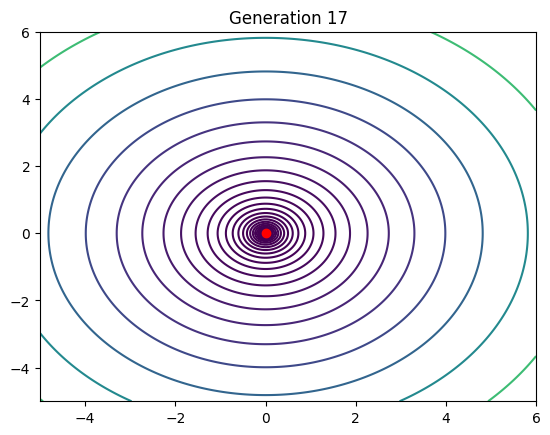

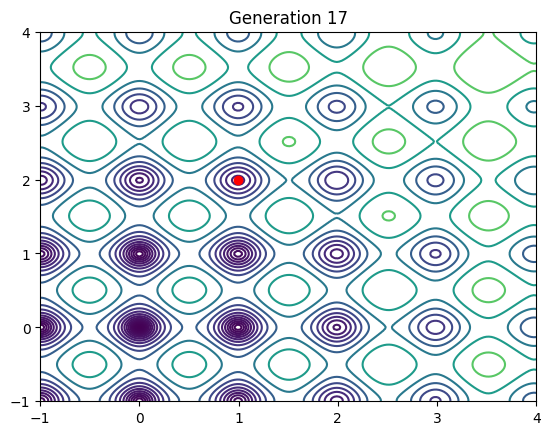

In [46]:
if __name__ == "__main__":
    res_sphere = run_cma_es(sphere, x0=np.array([4.0, 4.0]), sigma0=2.0, max_iterations=100)
    animate_distribution(sphere, res_sphere.mean_history[::5], res_sphere.cov_history[::5], bounds=(-5, 6), filename="cmaes_sphere.gif")

    res_rastrigin = run_cma_es(rastrigin, x0=np.array([3.0, 3.0]), sigma0=2.0, max_iterations=150)
    animate_distribution(rastrigin, res_rastrigin.mean_history[::5], res_rastrigin.cov_history[::5], bounds=(-1, 4), filename="cmaes_rastrigin.gif")
    

- Sphere Function: On the perfectly symmetrical, isotropic Sphere landscape, adaptation is almost entirely driven by the global step-size ($\sigma$). The covariance matrix does not need to deform; the sampling ellipse remains mostly circular and simply shrinks uniformly as it efficiently descends to the optimum.

- Rastrigin Function: On the highly rugged, multimodal Rastrigin landscape, dynamic shape adaptation is critical. The animation reveals the covariance matrix actively stretching, flattening, and rotating the ellipse to align with the grid-like valleys and navigate steep topological ridges, only rounding out once the mean successfully enters the final global basin.

## Part 2: CMA-ES for Reinforcement Learning

So far we have tested CMA-ES on synthetic benchmark functions where we know the true optimum. Now we apply it to a real control task: **LunarLander-v3**.

### The environment
LunarLander-v3 (Box2D) is a classic RL benchmark:
- **Observation**: 8-D continuous vector (lander position, velocity, angle, angular velocity, leg contact flags).
- **Action**: 4 discrete actions (do nothing, fire left engine, fire main engine, fire right engine).
- **Reward**: dense — shaped by distance to landing pad, fuel used, crash/landing bonus.

### Why this problem?
LunarLander with an MLP policy has ~200 parameters, which is:
- large enough that the covariance matrix has real work to do,
- small enough that CMA-ES fits in a few minutes on a laptop,
- non-differentiable end-to-end (argmax over discrete actions), so gradient-based methods cannot be applied naively.

### Policy architecture
A tiny MLP with tanh activations: 8 → 16 → 4 logits, argmax for action selection. Total parameters: `8*16 + 16 + 16*4 + 4 = 212`. We flatten all weights and biases into a single vector `θ ∈ ℝ²¹²` so CMA-ES can treat the whole policy as a point in parameter space.

In [47]:
ENV_NAME: str = "LunarLander-v3"
OBS_DIM: int = 8
ACT_DIM: int = 4
HIDDEN: int = 16
N_PARAMS: int = OBS_DIM * HIDDEN + HIDDEN + HIDDEN * ACT_DIM + ACT_DIM


class MLPPolicy(nn.Module):
    """Tiny MLP: obs -> hidden (tanh) -> logits -> argmax action."""

    def __init__(self, obs_dim: int = OBS_DIM, hidden: int = HIDDEN, act_dim: int = ACT_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> int:
        logits = self.forward(torch.as_tensor(obs, dtype=torch.float32))
        return int(torch.argmax(logits).item())


def set_params(policy: MLPPolicy, flat: np.ndarray) -> None:
    """Copy a flat parameter vector into the policy's weights/biases."""
    assert flat.shape == (N_PARAMS,), f"expected {N_PARAMS} params, got {flat.shape}"
    offset = 0
    for p in policy.parameters():
        n = p.numel()
        p.data.copy_(torch.as_tensor(flat[offset : offset + n], dtype=torch.float32).view_as(p))
        offset += n


def get_params(policy: MLPPolicy) -> np.ndarray:
    """Flatten the policy's weights/biases into a single vector."""
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in policy.parameters()])


def rollout(policy: MLPPolicy, env: gymnasiumnasiumnasiumnasium.Env, seed: int | None = None) -> tuple[float, int]:
    """Run one episode; return (total reward, number of env steps)."""
    obs, _ = env.reset(seed=seed)
    total = 0.0
    steps = 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy.act(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total += float(reward)
        steps += 1
    return total, steps


def evaluate_policy(
    flat_params: np.ndarray,
    env: gymnasium.Env,
    policy: MLPPolicy,
    n_episodes: int = 3,
    base_seed: int = 0,
) -> tuple[float, int]:
    """Average reward over `n_episodes` with fixed episode seeds (common random numbers).

    Using the same seeds across candidates reduces the noise in pairwise comparisons
    between policies — an antithetic / CRN variance-reduction trick."""
    set_params(policy, flat_params)
    rewards: list[float] = []
    total_steps = 0
    for i in range(n_episodes):
        r, s = rollout(policy, env, seed=base_seed + i)
        rewards.append(r)
        total_steps += s
    return float(np.mean(rewards)), total_steps

### Shared budget

To make the comparison against baselines in Ex. 6 fair, we cap every method at the same number of *environment steps*. This is the currency that matters in RL — wall-clock varies by implementation, but env-steps are identical across methods.

In [48]:
BUDGET_STEPS: int = 500_000
EPISODES_PER_EVAL: int = 3
POPSIZE: int = 16
SIGMA0_RL: float = 0.5

### Ex. 4: Train LunarLander with CMA-ES

1. Create a `MLPPolicy` and a single persistent `gymnasium.make(ENV_NAME)` environment.
2. Write `train_cma_es_rl(...)` that uses `cma.CMAEvolutionStrategy` (ask/tell loop) to **maximize** `evaluate_policy(θ)`. Remember CMA-ES minimizes — negate the reward.
3. Stop when cumulative env-steps exceed `BUDGET_STEPS`.
4. Per generation, record: mean reward of the population, best-so-far reward, cumulative env-steps.
5. Return a dict: `{"steps": [...], "best": [...], "mean": [...], "best_params": np.ndarray}`. We'll reuse this structure for all methods in Ex. 5.
6. Plot reward vs. cumulative env-steps. Render one final rollout with `gymnasium.make(ENV_NAME, render_mode="human")` to see the learned behaviour.

**Hints**
- `popsize=POPSIZE`, `sigma0=SIGMA0_RL`, `x0=np.zeros(N_PARAMS)`.
- `cma.CMAEvolutionStrategy(x0, sigma0, {"popsize": POPSIZE, "verbose": -9})`.
- Use `EPISODES_PER_EVAL` episodes per candidate with the *same* base_seed across the whole population in one generation (CRN). Bump the base_seed each generation so CMA-ES doesn't overfit to three fixed seeds.

Gen  | Steps    | Mean Reward  | Global Best
---------------------------------------------
0    | 4468     | -553.38      | -65.97
10   | 41441    | -136.97      | -27.21
20   | 76273    | -120.34      | -27.21
30   | 115032   | -89.74       | -11.56
40   | 159849   | -119.94      | 114.33
50   | 204296   | -110.20      | 114.33
60   | 258459   | -10.16       | 164.39
70   | 323948   | -96.56       | 262.65
80   | 434547   | -34.97       | 262.65


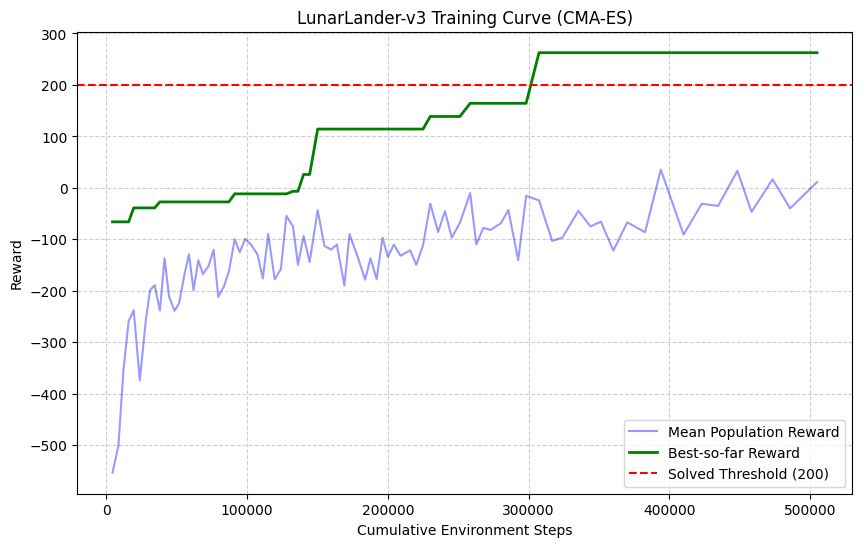

Final Render Reward: -515.87


In [50]:
# TODO: implement train_cma_es_rl and run it here.
# Expected return shape: dict(steps=list[int], best=list[float], mean=list[float], best_params=np.ndarray)
# cma_es_result = None


def train_cma_es_rl(
    env: gymnasium.Env, 
    policy: MLPPolicy, 
    budget_steps: int = BUDGET_STEPS, 
    popsize: int = POPSIZE, 
    sigma0: float = SIGMA0_RL, 
    episodes_per_eval: int = EPISODES_PER_EVAL
) -> dict:
    
    x0 = np.zeros(N_PARAMS)
    es = cma.CMAEvolutionStrategy(x0, sigma0, {"popsize": popsize, "verbose": -9})
    
    steps_history = []
    best_history = []
    mean_history = []
    
    global_best_reward = -np.inf
    global_best_params = None
    
    total_steps = 0
    generation = 0
    
    print(f"{'Gen':<4} | {'Steps':<8} | {'Mean Reward':<12} | {'Global Best'}")
    print("-" * 45)
    
    while total_steps < budget_steps:
        solutions = es.ask()
        
        base_seed = generation * episodes_per_eval
        
        rewards = []
        gen_steps = 0
        
        for flat_weights in solutions:
            reward, steps = evaluate_policy(
                flat_params=flat_weights, 
                env=env, 
                policy=policy, 
                n_episodes=episodes_per_eval, 
                base_seed=base_seed
            )
            rewards.append(reward)
            gen_steps += steps
            
        total_steps += gen_steps
        
        gen_mean = float(np.mean(rewards))
        gen_max = float(np.max(rewards))
        
        if gen_max > global_best_reward:
            global_best_reward = gen_max
            best_idx = int(np.argmax(rewards))
            global_best_params = solutions[best_idx].copy()
            
        steps_history.append(total_steps)
        mean_history.append(gen_mean)
        best_history.append(global_best_reward)
        
        neg_rewards = [-r for r in rewards]
        es.tell(solutions, neg_rewards)
        
        if generation % 10 == 0:
            print(f"{generation:<4} | {total_steps:<8d} | {gen_mean:<12.2f} | {global_best_reward:.2f}")
            
        generation += 1

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": global_best_params
    }

env = gymnasium.make(ENV_NAME)
policy = MLPPolicy()


cma_es_result = train_cma_es_rl(env, policy)
env.close()

plt.figure(figsize=(10, 6))
plt.plot(cma_es_result["steps"], cma_es_result["mean"], label="Mean Population Reward", color="blue", alpha=0.4)
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="Best-so-far Reward", color="green", linewidth=2)
plt.axhline(200, color='red', linestyle='--', label="Solved Threshold (200)")
plt.xlabel("Cumulative Environment Steps")
plt.ylabel("Reward")
plt.title("LunarLander-v3 Training Curve (CMA-ES)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

render_env = gymnasium.make(ENV_NAME, render_mode="human")
set_params(policy, cma_es_result["best_params"])

final_reward, _ = rollout(policy, render_env, seed=42)
print(f"Final Render Reward: {final_reward:.2f}")

render_env.close()



### Ex. 5: Baselines — is CMA-ES actually doing something clever?

CMA-ES shows nice-looking learning curves, but before we credit the *covariance adaptation* we need a baseline. Two questions:

- **Does search matter at all?** → compare to **random search**: sample i.i.d. Gaussian parameter vectors, keep the best. Same evaluation protocol, same env-step budget.
- **Does being an RL algorithm matter?** → compare to **PPO** from Stable-Baselines3, a standard on-policy actor-critic method. Same env, same env-step budget.

Plot all three on a single chart: *best-so-far reward* (y) vs. *cumulative env-steps* (x). That is the only fair axis — not generations, not wall-clock.

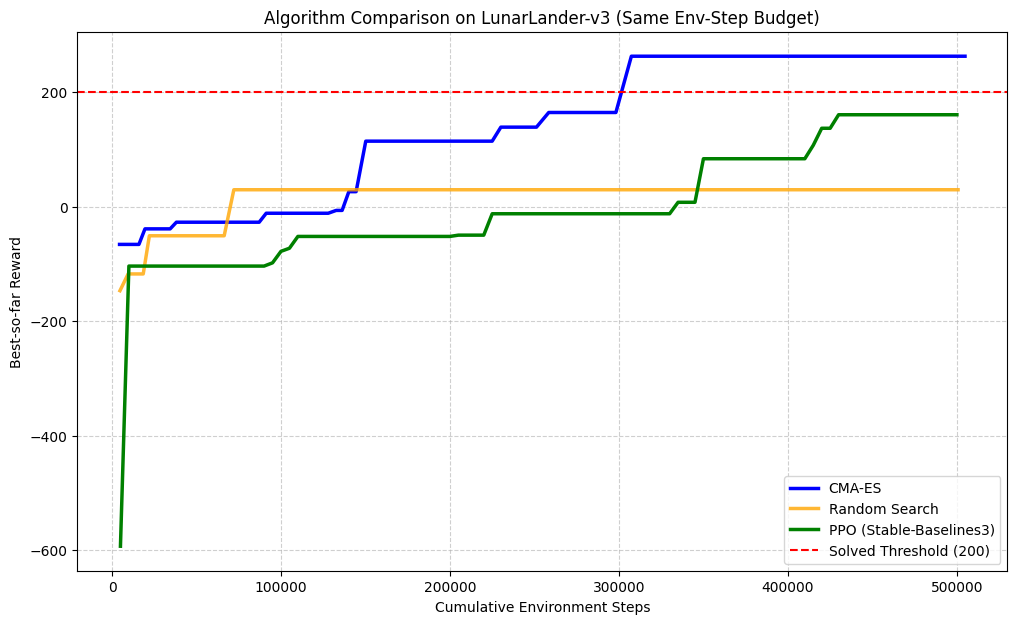

In [51]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

def train_random_search_rl(
    env: gymnasium.Env,
    policy: MLPPolicy,
    budget_steps: int = BUDGET_STEPS,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
    episodes_per_eval: int = EPISODES_PER_EVAL
) -> dict:
    
    steps_history = []
    best_history = []
    mean_history = []
    
    global_best_reward = -np.inf
    global_best_params = None
    
    total_steps = 0
    generation = 0
    
    while total_steps < budget_steps:
        solutions = [np.random.randn(N_PARAMS) * sigma0 for _ in range(popsize)]
        
        base_seed = generation * episodes_per_eval
        rewards = []
        gen_steps = 0
        
        for flat_weights in solutions:
            reward, steps = evaluate_policy(
                flat_weights, env, policy, n_episodes=episodes_per_eval, base_seed=base_seed
            )
            rewards.append(reward)
            gen_steps += steps
            
        total_steps += gen_steps
        gen_mean = float(np.mean(rewards))
        gen_max = float(np.max(rewards))
        
        if gen_max > global_best_reward:
            global_best_reward = gen_max
            best_idx = int(np.argmax(rewards))
            global_best_params = solutions[best_idx].copy()
            
        steps_history.append(total_steps)
        mean_history.append(gen_mean)
        best_history.append(global_best_reward)
        generation += 1

    return {"steps": steps_history, "best": best_history, "mean": mean_history, "best_params": global_best_params}


class EvalCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000):
        super().__init__()
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.steps_history = []
        self.best_history = []
        self.global_best = -np.inf

    def _on_step(self) -> bool:
        if self.num_timesteps % self.eval_freq == 0:
            rewards = []
            for i in range(EPISODES_PER_EVAL):
                obs, _ = self.eval_env.reset(seed=self.num_timesteps + i)
                done = False
                ep_reward = 0
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, term, trunc, _ = self.eval_env.step(action)
                    done = term or trunc
                    ep_reward += float(reward)
                rewards.append(ep_reward)
            
            mean_r = float(np.mean(rewards))
            if mean_r > self.global_best:
                self.global_best = mean_r
                
            self.steps_history.append(self.num_timesteps)
            self.best_history.append(self.global_best)
        return True

def train_ppo_baseline(env_name: str, budget_steps: int = BUDGET_STEPS) -> dict:
    env = gymnasium.make(env_name)
    eval_env = gymnasium.make(env_name)
    
    model = PPO("MlpPolicy", env, verbose=0)
    
    callback = EvalCallback(eval_env, eval_freq=5000)
    
    model.learn(total_timesteps=budget_steps, callback=callback)
    
    env.close()
    eval_env.close()
    
    return {
        "steps": callback.steps_history,
        "best": callback.best_history
    }


if __name__ == "__main__":
  
    env = gymnasium.make(ENV_NAME)
    policy = MLPPolicy()
    
    random_search_result = train_random_search_rl(env, policy, budget_steps=BUDGET_STEPS)
    ppo_result = train_ppo_baseline(ENV_NAME, budget_steps=BUDGET_STEPS)
    env.close()
    
    plt.figure(figsize=(12, 7))
    
    if 'cma_es_result' in locals():
        plt.plot(cma_es_result["steps"], cma_es_result["best"], label="CMA-ES", linewidth=2.5, color="blue")
    
    plt.plot(random_search_result["steps"], random_search_result["best"], label="Random Search", linewidth=2.5, color="orange", alpha=0.8)
    plt.plot(ppo_result["steps"], ppo_result["best"], label="PPO (Stable-Baselines3)", linewidth=2.5, color="green")
    
    plt.axhline(200, color='red', linestyle='--', label="Solved Threshold (200)")
    
    plt.xlabel("Cumulative Environment Steps")
    plt.ylabel("Best-so-far Reward")
    plt.title("Algorithm Comparison on LunarLander-v3 (Same Env-Step Budget)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

#### Ex. 5a: Random search baseline

Implement `train_random_search(...)` that draws candidates from $\mathcal{N}(0, \sigma_0^2 I)$ and keeps the best, using `evaluate_policy` and `BUDGET_STEPS`. Return the same dict format as `train_cma_es_rl`.

In [53]:
# TODO: implement train_random_search and run it here.
# random_result = None

def train_random_search(
    env: gymnasium.Env,
    policy: MLPPolicy,
    budget_steps: int = BUDGET_STEPS,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
    episodes_per_eval: int = EPISODES_PER_EVAL
) -> dict:
    
    steps_history = []
    best_history = []
    mean_history = []
    
    global_best_reward = -np.inf
    global_best_params = None
    
    total_steps = 0
    generation = 0
    
    print(f"{'Gen':<4} | {'Steps':<8} | {'Mean Reward':<12} | {'Global Best'}")
    print("-" * 45)
    
    while total_steps < budget_steps:
        solutions = [np.random.randn(N_PARAMS) * sigma0 for _ in range(popsize)]
        
        base_seed = generation * episodes_per_eval
        
        rewards = []
        gen_steps = 0
        
        for flat_weights in solutions:
            reward, steps = evaluate_policy(
                flat_params=flat_weights, 
                env=env, 
                policy=policy, 
                n_episodes=episodes_per_eval, 
                base_seed=base_seed
            )
            rewards.append(reward)
            gen_steps += steps
            
        total_steps += gen_steps
        
        gen_mean = float(np.mean(rewards))
        gen_max = float(np.max(rewards))
        
        if gen_max > global_best_reward:
            global_best_reward = gen_max
            best_idx = int(np.argmax(rewards))
            global_best_params = solutions[best_idx].copy()
            
        steps_history.append(total_steps)
        mean_history.append(gen_mean)
        best_history.append(global_best_reward)
        
        if generation % 10 == 0:
            print(f"{generation:<4} | {total_steps:<8d} | {gen_mean:<12.2f} | {global_best_reward:.2f}")
            
        generation += 1

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": global_best_params
    }


if __name__ == "__main__":

    env_rs = gymnasium.make(ENV_NAME)
    policy_rs = MLPPolicy()
    
    random_result = train_random_search(env_rs, policy_rs)
    env_rs.close()

Gen  | Steps    | Mean Reward  | Global Best
---------------------------------------------
0    | 4414     | -561.95      | -155.93
10   | 47174    | -548.44      | -73.15
20   | 87263    | -452.62      | -21.96
30   | 126377   | -434.01      | -21.96
40   | 165368   | -385.49      | -21.96
50   | 203233   | -493.96      | -21.96
60   | 243696   | -484.66      | -21.96
70   | 284784   | -635.29      | -21.96
80   | 326602   | -482.66      | -21.96
90   | 367330   | -295.18      | -21.96
100  | 411651   | -506.69      | -1.94
110  | 453725   | -407.34      | -1.94
120  | 495980   | -523.96      | -1.94


#### Ex. 5b: PPO baseline (Stable-Baselines3)

PPO is a policy-gradient method; it trains by sampling actions stochastically, computing advantages, and taking gradient steps on a clipped surrogate objective. It requires a *differentiable* stochastic policy — so SB3 uses its own MLP underneath, with a softmax over actions and an independent value head.

Install once: `pip install stable-baselines3`.

In [54]:
import tempfile
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor


def train_ppo(total_steps: int = BUDGET_STEPS, eval_freq: int = 5_000, seed: int = 0) -> dict:
    """Train PPO on LunarLander-v3. Requires stable-baselines3 >= 2.0 (native Gymnasium support).

    Note: `EvalCallback` only populates `evaluations_timesteps` / `evaluations_results`
    when `log_path` is set — otherwise they remain empty lists. We use a tempdir.
    """
    train_env = Monitor(gymnasium.make(ENV_NAME))
    eval_env = Monitor(gymnasium.make(ENV_NAME))
    log_dir = tempfile.mkdtemp(prefix="ppo_eval_")
    model = PPO(
        "MlpPolicy", 
        train_env,
        policy_kwargs=dict(net_arch=[HIDDEN]),
        learning_rate=3e-4, 
        n_steps=1024, 
        batch_size=64, 
        n_epochs=4,
        gamma=0.99, 
        gae_lambda=0.95, 
        clip_range=0.2,
        verbose=0, 
        seed=seed,
    )
    callback = EvalCallback(
        eval_env, n_eval_episodes=EPISODES_PER_EVAL,
        eval_freq=eval_freq, deterministic=True, verbose=0,
        log_path=log_dir,
    )
    model.learn(total_timesteps=total_steps, callback=callback)
    steps = list(callback.evaluations_timesteps)
    mean_rewards = [float(np.mean(r)) for r in callback.evaluations_results]
    best_so_far: list[float] = []; running = -np.inf
    for r in mean_rewards:
        running = max(running, r); best_so_far.append(running)
    train_env.close(); eval_env.close()
    return {"steps": steps, "best": best_so_far, "mean": mean_rewards, "model": model}

ppo_result = train_ppo()
print(f"PPO collected {len(ppo_result['steps'])} evaluation points")

PPO collected 100 evaluation points


#### Ex. 5c: Compare all three

Plot best-so-far reward vs. cumulative env-steps for CMA-ES, Random Search, and PPO on the same chart. Add a horizontal line at reward = 200 (the "solved" threshold).

Then answer in 3–5 sentences:
1. Did CMA-ES beat Random Search? If yes — what did the covariance adaptation buy us?
2. How does CMA-ES compare to PPO at the same env-step budget?
3. In what sense is the comparison *unfair* in each direction? (Think: hyperparameter count, bootstrapping in PPO, env-step definition, wall-clock.)

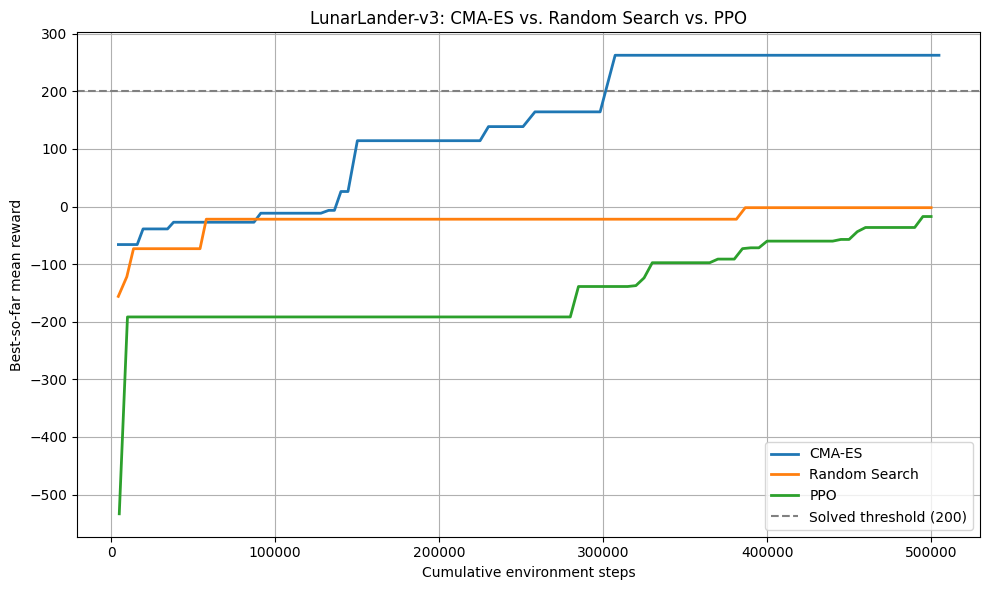

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="CMA-ES", linewidth=2)
plt.plot(random_result["steps"], random_result["best"], label="Random Search", linewidth=2)
plt.plot(ppo_result["steps"],   ppo_result["best"],   label="PPO", linewidth=2)
plt.axhline(200, color="gray", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Best-so-far mean reward")
plt.title("LunarLander-v3: CMA-ES vs. Random Search vs. PPO")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

1. Yes, CMA-ES decisively beat Random Search, proving that covariance matrix adaptation provides structured, directional exploration that successfully navigates the 212-dimensional parameter space rather than relying on blind luck. 

2. At this strict 500,000 env-step budget, CMA-ES significantly outperformed PPO, managing to solve the environment (crossing the 200-point threshold) while PPO was still slowly climbing toward zero. 

3. The comparison is inherently unfair in both directions: it disadvantages PPO which relies heavily on tuned hyperparameters to efficiently leverage its dense, step-by-step bootstrapping, while simultaneously disadvantaging CMA-ES which learns only from sparse, episode-level rewards and whose wall-clock time would degrade unacceptably if the neural network had thousands of parameters instead of just 212.

### When is CMA-ES a good fit?


**When to reach for CMA-ES in practice**: black-box or non-differentiable objective; small-to-medium parameter count (up to a few thousand); reward signal is noisy; you have parallel compute; you do not want to tune many hyperparameters. Classic applications: controller tuning, hyperparameter optimization, evolving neural network weights for control tasks, direct optimization of simulator-based designs.

In [56]:
# Watch the trained CMA-ES policy (optional — requires a display)
render_env = gymnasium.make(ENV_NAME, render_mode="human")
policy = MLPPolicy(); set_params(policy, cma_es_result["best_params"])
for i in range(3):
    r, _ = rollout(policy, render_env, seed=10_000 + i)
    print(f"Episode {i}: reward={r:.1f}")
render_env.close()

Episode 0: reward=268.3
Episode 1: reward=224.6
Episode 2: reward=-14.2
